# Figure S14: Cross-metric correlation of preprocessed dMRI contrast quality effects

Figure S14 extends the Figure 6-style cross-metric correspondence to all configured microstructural metrics using Pearson correlations of bundle-wise quality effects for `t1post_dwi_contrast`.


In [9]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(scales)
  library(grid)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s14_dir <- fs::path(project_root, "figures", "Supplement", "FigureS14")
fs::dir_create(figure_s14_dir, recurse = TRUE)

quality_effect_file <- fs::path(project_root, "data", "quality_effects", "quality_effects_all_outputs.rds")
if (!file.exists(quality_effect_file)) stop("Missing assembled quality-effect file: ", quality_effect_file)

df_quality_all <- readRDS(quality_effect_file)
required_cols <- c("bundle", "metric", "qc_metric", "source", "output_type", "qc_effect_size")
missing_cols <- setdiff(required_cols, names(df_quality_all))
if (length(missing_cols) > 0) {
  stop("Assembled quality-effect data missing required columns: ", paste(missing_cols, collapse = ", "))
}



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS14/S14_cross_metric_quality_effect_correlation_clustered.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS14/S14_cross_metric_quality_effect_correlation_clustered.png



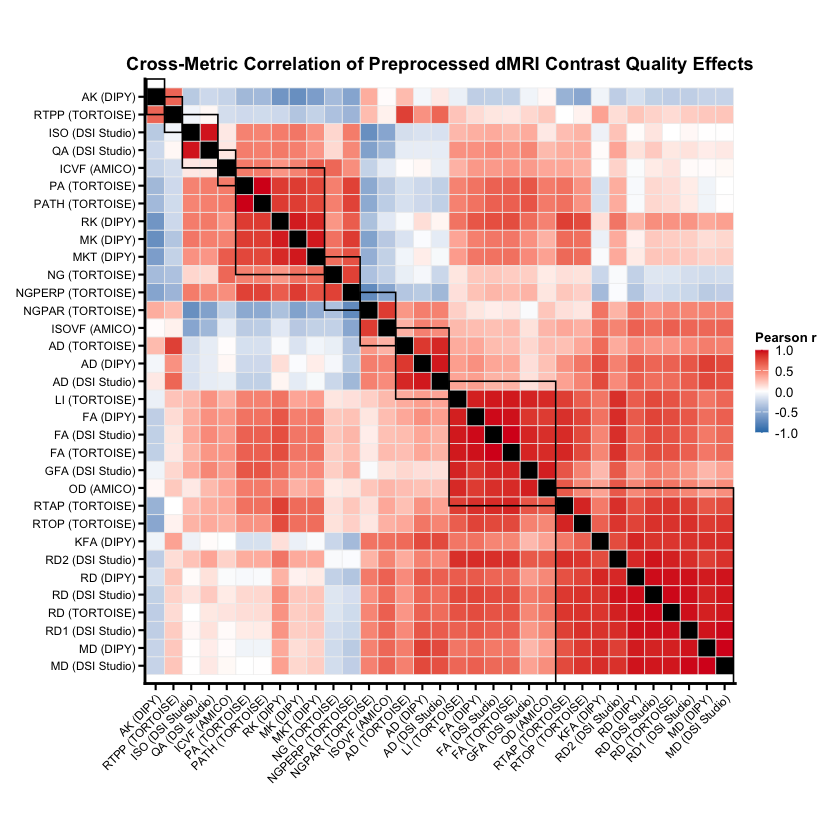

In [10]:
metrics_keep <- trimws(as.character(config$microstructural_metrics))
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")

metric_meta <- tibble(metric = metrics_keep) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    metric_short = if_else(
      str_detect(metric, "_"),
      str_to_upper(str_remove(metric, "^[^_]+_")),
      str_to_upper(metric)
    ),
    metric_label = paste0(metric_short, " (", software, ")")
  ) %>%
  filter(software %in% software_order)

if (nrow(metric_meta) < 2) {
  stop("Need at least two configured metrics from the supported software groups.")
}

label_map <- setNames(metric_meta$metric_label, metric_meta$metric)

df_qc <- df_quality_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    qc_metric == "t1post_dwi_contrast",
    metric %in% metric_meta$metric,
    !is.na(bundle),
    !is.na(qc_effect_size)
  ) %>%
  transmute(
    bundle = as.character(bundle),
    metric = as.character(metric),
    qc_effect_size = as.numeric(qc_effect_size)
  )

if (nrow(df_qc) == 0) {
  stop("No rows for FigureS14 with t1post_dwi_contrast quality effects.")
}

wide_effects <- df_qc %>%
  distinct(bundle, metric, qc_effect_size) %>%
  pivot_wider(names_from = metric, values_from = qc_effect_size)

metric_cols <- intersect(metric_meta$metric, names(wide_effects))
if (length(metric_cols) < 2) {
  stop("Need at least two metrics with data to compute the correlation heatmap.")
}

mat <- wide_effects %>%
  select(all_of(metric_cols)) %>%
  as.matrix()

cor_mat <- cor(mat, method = "pearson", use = "pairwise.complete.obs")

# Same clustering treatment as S13.
# If you want sign-insensitive clustering, use abs(cor_mat) instead.
dist_mat <- as.dist(1 - cor_mat)
hc <- hclust(dist_mat, method = "average")
metric_order <- colnames(cor_mat)[hc$order]

heat_df <- as.data.frame(as.table(cor_mat), stringsAsFactors = FALSE) %>%
  rename(metric_y = Var1, metric_x = Var2, rho = Freq) %>%
  mutate(
    is_diag = metric_x == metric_y,
    metric_x = factor(metric_x, levels = metric_order),
    metric_y = factor(metric_y, levels = rev(metric_order))
  )

# Major cluster annotation boxes
k_clusters <- min(10, length(metric_order))
cluster_assign <- cutree(hc, k = k_clusters)

cluster_df <- tibble(
  metric = names(cluster_assign),
  cluster = unname(cluster_assign),
  x = match(names(cluster_assign), metric_order)
) %>%
  arrange(x)

cluster_bounds <- cluster_df %>%
  group_by(cluster) %>%
  summarise(
    xmin = min(x) - 0.5,
    xmax = max(x) + 0.5,
    .groups = "drop"
  ) %>%
  mutate(
    ymin = length(metric_order) - xmax + 0.5,
    ymax = length(metric_order) - xmin + 1.5
  )

p_s14 <- ggplot() +
  geom_tile(
    data = filter(heat_df, !is_diag),
    aes(x = metric_x, y = metric_y, fill = rho),
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_tile(
    data = filter(heat_df, is_diag),
    aes(x = metric_x, y = metric_y),
    fill = "black",
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_rect(
    data = cluster_bounds,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
    inherit.aes = FALSE,
    fill = NA,
    color = "black",
    linewidth = 0.45
  ) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "#FFFFFF",
    high = "#D7191C",
    midpoint = 0,
    limits = c(-1, 1),
    breaks = c(-1, -0.5, 0, 0.5, 1),
    oob = squish,
    name = "Pearson r"
  ) +
  scale_x_discrete(labels = label_map[metric_order]) +
  scale_y_discrete(labels = rev(label_map[metric_order])) +
  coord_fixed(clip = "off") +
  labs(
    x = NULL,
    y = NULL,
    title = "Cross-Metric Correlation of Preprocessed dMRI Contrast Quality Effects"
  ) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 8,
    axis_text_pt = 8,
    legend_title_pt = 8,
    legend_text_pt = 8,
    base_size_pt = 8
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    panel.grid = element_blank(),
    plot.title = element_text(size = 11, hjust = 0.5),
    legend.key.height = unit(10, "pt"),
    legend.key.width = unit(8, "pt"),
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10)
  )

p_s14

save_plot_outputs(
  plot_obj = p_s14,
  stub = "S14_cross_metric_quality_effect_correlation_clustered",
  out_dir = figure_s14_dir,
  width_in = 14,
  height_in = 14
)